<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
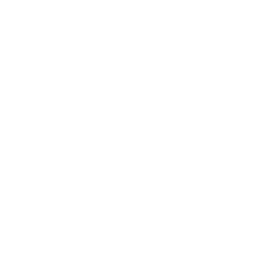
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">化学反応器異常事象の診断</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 異常事象時にT²超過を引き起こす変数を特定 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

連続槽型反応器(CSTR)は、冷却材供給の劣化により熱的異常事象へと陥った。通常運転では、冷却材流量・反応器温度・ジャケット温度は単一の工程負荷軸に沿って連動して動く。100件の正常運転観測データから3成分のMVPモデルを構築し、`PROC MVPDIAGNOSE`を用いて100件の異常観測データをこのモデルに対してスコアリングする。ホテリングの*T*二乗統計量を変数別寄与度に分解すると、熱結合トリオ―`jacket_temp`、`coolant_flow`、`reactor_temp`―が超過を牽引する変数として突出しており、運用チームを冷却材サブシステムへ直接誘導する。


## データソース

| データセット | 役割 | 観測数 |
|---|---|---|
| `reactor_normal` | MVPモデル用の正常運転トレーニングデータ | 100 |
| `reactor_upset` | モデルに対してスコアリングされる異常事象観測データ | 100 |

測定される6変数は `reactor_temp`(反応器温度、C)、`coolant_flow`(冷却材流量、L/min)、
`jacket_temp`(ジャケット温度、C)、`feed_conc`(供給濃度、g/L)、`pressure`(圧力、bar)である。
両データセットは共通の潜在的*工程負荷*からシミュレートされており、正常データは実際のCSTRが
示すのと同じ相関構造を持つ。異常データでは冷却材供給の喪失が注入され、その構造が崩れる。


## ステップ1 ― 正常運転MVPモデルの学習

通常運転は潜在的な工程負荷に支配されている。負荷が高くなるほど冷却材流量は低下し、
反応器温度とジャケット温度は上昇する。`PROC MVPMODEL`は100件の正常観測データから
3つの主成分を抽出し、`OUTMODEL=`でそれを保存することで、診断ステップが新しいデータを
同じ参照モデルに対してスコアリングできるようにする。


In [1]:
データ reactor_normal;
  呼出 streaminit(7);
  繰返 t = 1 から 100;
    LOAD = rand('normal', 0, 1);                 /* 潜在的な工程負荷 */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    出力;
  終了;
実行;

処理 mvpmodel データ=reactor_normal outmodel=reactor_model;
  見出 reactor_temp='反応器温度' coolant_flow='冷却材流量' jacket_temp='ジャケット温度'
        feed_conc='供給濃度' pressure='圧力';
  変数 reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
実行;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
              反応器温度     冷却材流量   ジャケット温度      供給濃度        圧力
  反応器温度     1.0000   -0.9611    0.9530   -0.0726    0.9662
  冷却材流量    -0.9611    1.0000   -0.9636    0.0281   -0.9712
  ジャケット温度    0.9530   -0.9636    1.0000    0.0008    0.9720
  供給濃度     -0.0726    0.0281    0.0008    1.0000   -0.0326
  圧力        0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## ステップ2 ― 異常事象のスコアリングと*T*二乗の分解

異常事象では冷却材流量がおよそ12 L/min低下し、反応器温度とジャケット温度は上昇する―
正常時の冷却材/温度の連動関係が崩れる。`PROC MVPDIAGNOSE`は各異常観測を参照モデルに
対してスコアリングし、標準化スコアと残差を`OUT=`に、変数別の*T*二乗寄与度を
`OUTCONTRIB=`に書き出す。すべての観測が管理限界を大きく超えており、単発ノイズではなく
持続的な多変量逸脱であることを裏付けている。


In [2]:
データ reactor_upset;
  呼出 streaminit(101);
  繰返 t = 1 から 100;
    LOAD = rand('normal', 0, 1);
    /* 冷却材ポンプの劣化: 流量が低下し、温度が暴走する */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    obs_time = t;
    出力;
  終了;
実行;

処理 mvpdiagnose データ=reactor_upset 模型=reactor_model
                 out=reactor_scores;
  見出 reactor_temp='反応器温度' coolant_flow='冷却材流量' jacket_temp='ジャケット温度'
        feed_conc='供給濃度' pressure='圧力';
  変数 reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
実行;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100
  Variables Diagnosed: 反応器温度, 冷却材流量, ジャケット温度, 供給濃度, 圧力

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## ステップ3 ― 平均寄与度のランキング

`OUTCONTRIB=`はスコアリングされた観測ごとに1行を書き出し、工程変数ごとに
`<variable>_CONTRIB`列を持つ。これらの列を平均すると各変数の異常事象への
平均寄与度が得られ、転置によって1行のサマリーを変数/値のわかりやすい表に
再構成し、異常の原因変数をランク付けする。


In [3]:
処理 MEANS データ=reactor_contrib mean NOPRINT;
  変数 reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  出力 out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
実行;

処理 TRANSPOSE データ=contrib_means out=contrib_long name=metric;
  変数 mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
実行;

/* 読みやすい変数名と平均寄与度の値を付与する */
データ contrib_ranked;
  設定 contrib_long;
  長さ variable $24;
  もし      metric = 'mc_reactor_temp' なら variable = '反応器温度';
  他 もし metric = 'mc_coolant_flow' なら variable = '冷却材流量';
  他 もし metric = 'mc_jacket_temp'  なら variable = 'ジャケット温度';
  他 もし metric = 'mc_feed_conc'    なら variable = '供給濃度';
  他 もし metric = 'mc_pressure'     なら variable = '圧力';
  mean_contrib = col1;
  保持 variable mean_contrib;
実行;

処理 SORT データ=contrib_ranked;
  基準 DESCENDING mean_contrib;
実行;

処理 PRINT データ=contrib_ranked noobs;
  見出 variable='工程変数' mean_contrib='平均T²寄与度';
  変数 variable mean_contrib;
実行;



                 工程変数             平均T²寄与度
---------------------  ------------------
ジャケット温度                     4177.66720283
冷却材流量                       2882.19501987
反応器温度                       1602.04200377
圧力                           280.73140863
供給濃度                          61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/28cf7afc-6c75-4598-884c-8b004bc7c821/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## ステップ4 ― 寄与度プロット

寄与度プロットは診断結果を一目で示す: 熱的に連動したトリオ―`jacket_temp`、
`coolant_flow`、`reactor_temp`―が`feed_conc`と`pressure`を圧倒しており、後者は
ほとんど目立たない。突出した3本のバーはまさに冷却ループで結び付けられた変数
そのものであり、故障が供給や圧力の問題ではなく明確に熱的な問題であることを示す。



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


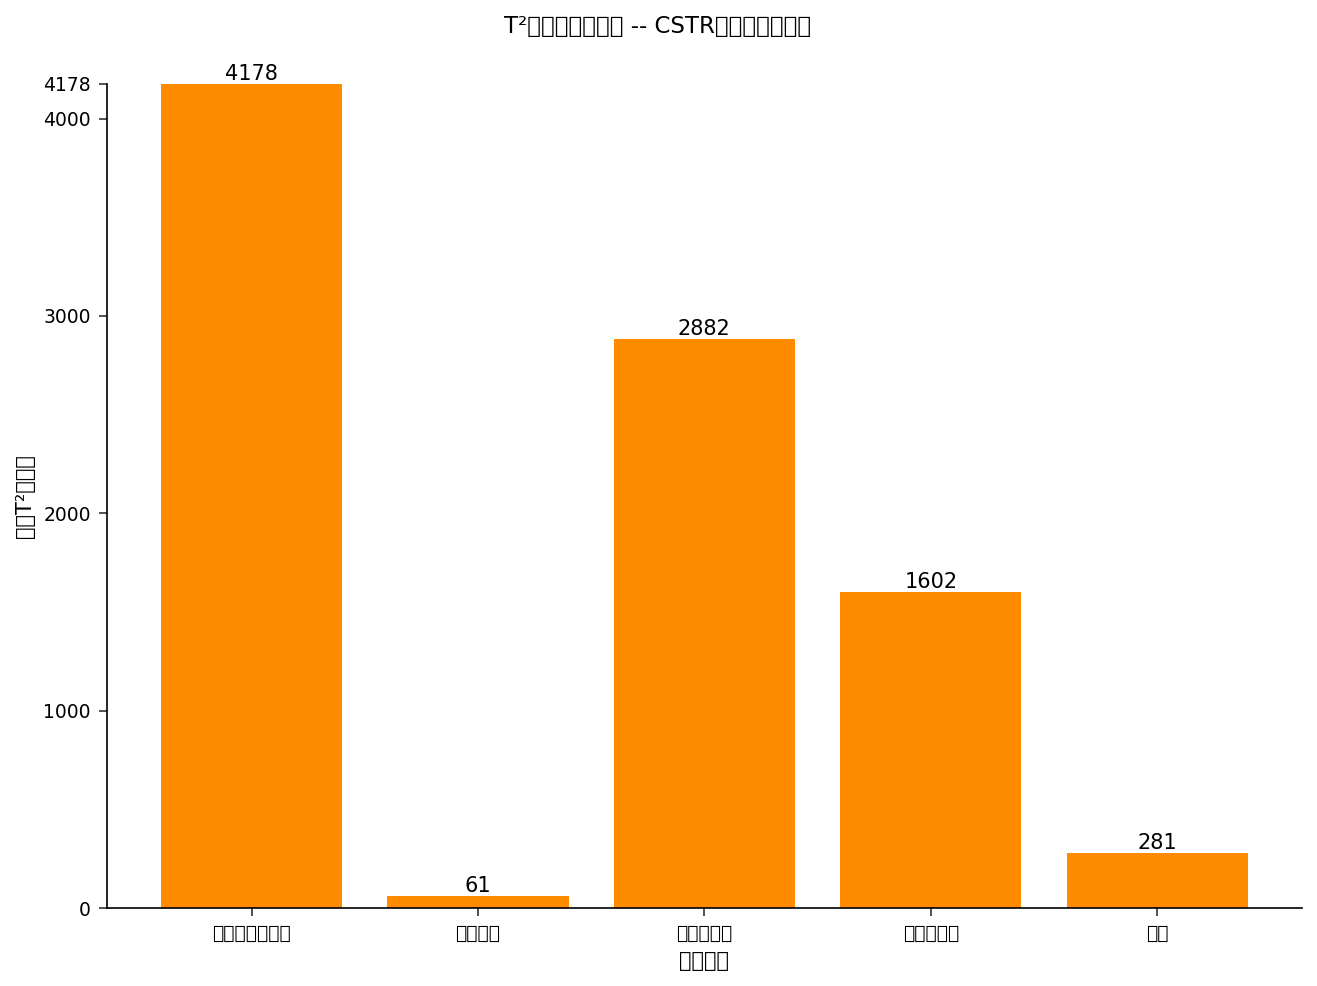

In [4]:
処理 SGPLOT データ=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS 見出='工程変数';
  YAXIS 見出='平均T²寄与度';
  表題 'T²寄与度プロット -- CSTR冷却材喪失異常';
実行;


## ステップ5 ― *T*二乗の管理タイムライン

各観測の*T*二乗値をモデルの管理限界とともにプロットすると、逸脱が持続的である
ことがわかる: すべての異常観測が限界の参照線を桁違いに上回っている。この期間中
に回復は見られず、冷却材サブシステムが修理されるまで持続するハードウェア故障
と整合的である。



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


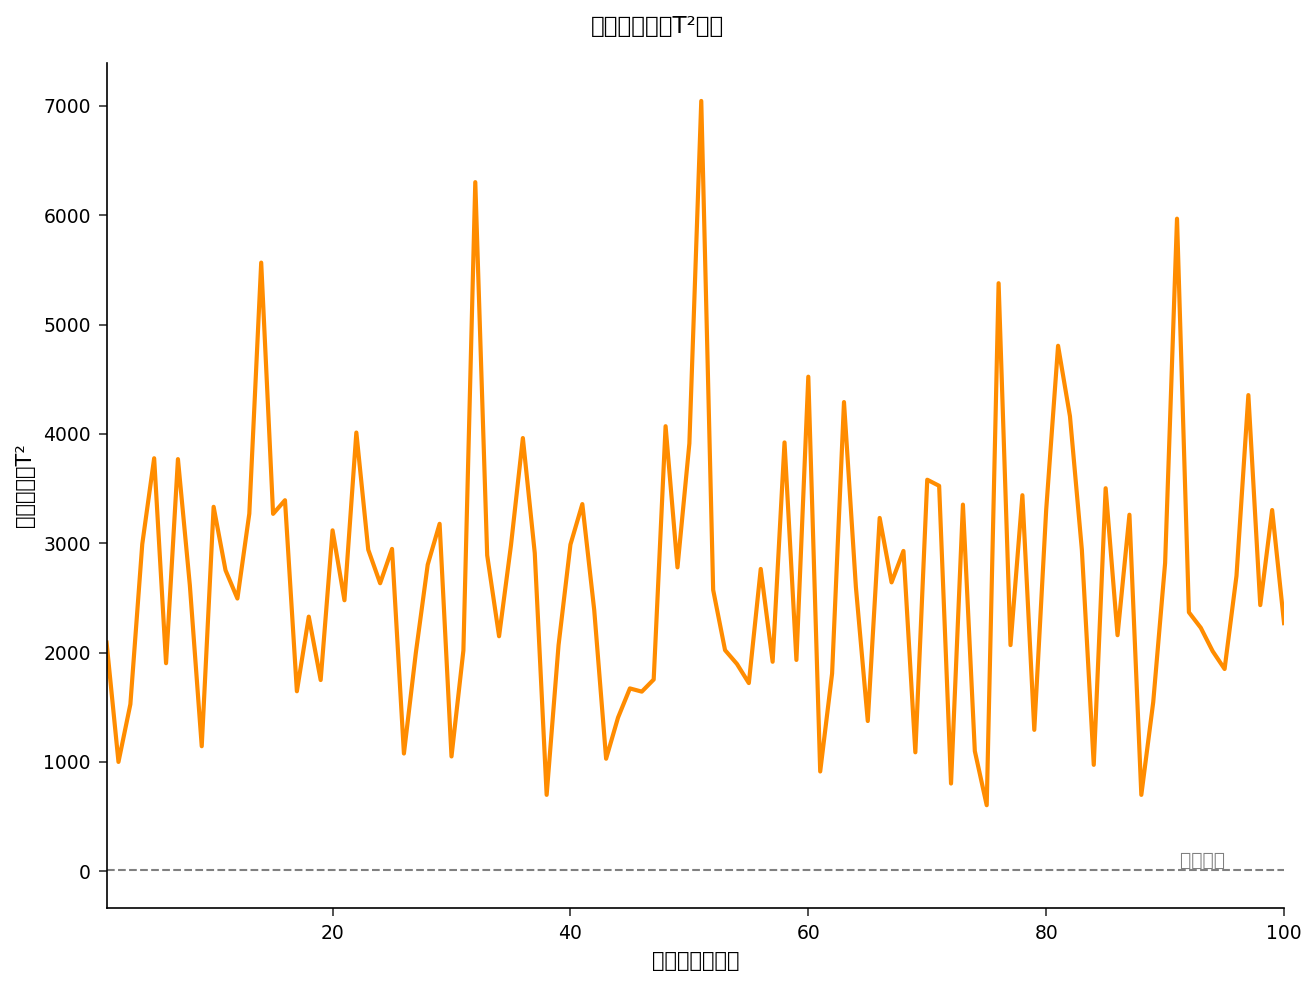

In [5]:
処理 SGPLOT データ=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  見出='管理限界'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS 見出='異常時観測番号';
  YAXIS 見出='ホテリングT²';
  表題 '異常事象中のT²推移';
実行;


## 所見と是正措置

- **主要因**: `jacket_temp`、`coolant_flow`、`reactor_temp`の3変数で、
  *T*二乗シグナルのほぼすべてを占める。これらの平均寄与度は`pressure`より
  約6〜15倍、`feed_conc`より約26〜68倍(一桁半から二桁近く)大きい。
- **根本原因**: 冷却材供給の喪失。3変数のうち`coolant_flow`だけが*操作可能*な
  変数であり、温度上昇は冷却喪失に伴う下流の結果であるため、対処すべき実際の
  故障は冷却材サブシステムである。
- **管理状態**: 100件の異常観測すべてが*T*二乗限界を超過しており、一時的な
  現象ではなく持続的な逸脱であることを示している。
- **是正措置**: 冷却材ポンプを点検・オーバーホールする。将来の供給喪失が
  温度ループへ波及する前に単変量アラームで検知できるよう、冗長な冷却材流量
  トランスミッタを追加する。


## ランク付けされた寄与度のエクスポート

ランク付けされた寄与度テーブルを、事後報告書とダウンストリームのダッシュ
ボード向けにCSVへ書き出す。


In [6]:
処理 EXPORT データ=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
実行;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 社外秘
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供
</div>
</div>